<a href="https://colab.research.google.com/github/eldaindahsl1203-hash/clustering_produk_skincare/blob/main/Analisis_Lanjutan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SETUP DATA**

In [1]:
# =========================
# CORE
# =========================
import numpy as np
import pandas as pd
import os
import json

# =========================
# VISUALISASI
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# TEXT PROCESSING (TF-IDF)
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================
# CLUSTERING & EVALUATION
# =========================
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score
)

# =========================
# DIMENSION REDUCTION / SIMILARITY
# =========================
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# PREPROCESS / SAMPLING
# =========================
from sklearn.utils import resample

# =========================
# OPTIONAL (kalau kamu pakai advanced analysis)
# =========================
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# SYSTEM / FILE
# =========================
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/Machine_Learning/Proyek/'
data_path = '/content/drive/My Drive/Machine_Learning/Proyek/outputS/'

# 1. DATA HASIL CLUSTERING (DATA UTAMA)
df = pd.read_excel(data_path + 'hasil_clustering_skincare_lengkap.xlsx')

# 2. METRIK EVALUASI CLUSTERING
df_metrics = pd.read_excel(data_path + 'evaluasi_metrik_clustering.xlsx')

# 3. DISTRIBUSI CLUSTER (SUMMARY ANALISIS)
df_dist = pd.read_excel(data_path + 'distribusi_ukuran_cluster_all_algos.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**DEFINISI FEATURE**

In [3]:
# GANTI bagian DEFINISI FEATURE menjadi:
cluster_cols = ['cluster_kmeans', 'cluster_agg', 'cluster_gmm']

# Kolom fitur afterUse yang kita tahu ada 17 label
afteruse_labels = [
    'Acne Fighting', 'Acne Trigger', 'Anti-Aging', 'Brightening',
    'Dark Spots', 'Drying', 'Eczema', 'Good For Oily Skin',
    'Hydrating', 'Irritating', 'May Worsen Oily Skin',
    'Reduces Irritation', 'Reduces Large Pores', 'Redness Reducing',
    'Rosacea', 'Scar Healing', 'Skin Texture'
]

# Buat ulang kolom biner dari kolom afterUse yang ada di df
from sklearn.preprocessing import MultiLabelBinarizer
mlb_reload = MultiLabelBinarizer(classes=afteruse_labels)
afteruse_series_reload = df['afterUse'].fillna('').str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip()]
)
afteruse_reload = mlb_reload.fit_transform(afteruse_series_reload)
afteruse_df_reload = pd.DataFrame(
    afteruse_reload, columns=afteruse_labels, index=df.index
)

# Tambahkan ke df
for col in afteruse_labels:
    df[col] = afteruse_df_reload[col]

feature_cols = afteruse_labels

**INTERPRETASI & PELABELAN CLUSTER**

In [4]:
def extract_cluster_keywords(df, cluster_col, text_col='afterUse'):
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
    X = tfidf.fit_transform(df[text_col].fillna(""))

    terms = np.array(tfidf.get_feature_names_out())
    results = {}

    for c in sorted(df[cluster_col].unique()):
        idx = df[df[cluster_col] == c].index
        mean_vec = X[idx].mean(axis=0).A1
        top_idx = mean_vec.argsort()[-10:][::-1]
        results[c] = terms[top_idx].tolist()

    return results


keywords_kmeans = extract_cluster_keywords(df, 'cluster_kmeans')
keywords_agg = extract_cluster_keywords(df, 'cluster_agg')
keywords_gmm = extract_cluster_keywords(df, 'cluster_gmm')

print(keywords_kmeans)

{np.int64(0): ['eczema', 'trigger', 'acne', 'brightening', 'irritation', 'worsen', 'reduces', 'drying', 'oily', 'skin'], np.int64(1): ['skin', 'reduces', 'large', 'pores', 'good', 'drying', 'oily', 'fighting', 'acne', 'irritating'], np.int64(2): ['trigger', 'worsen', 'acne', 'oily', 'skin', 'brightening', 'drying', 'hydrating', 'eczema', 'irritation'], np.int64(3): ['skin', 'texture', 'spots', 'dark', 'redness', 'reducing', 'anti', 'aging', 'brightening', 'scar'], np.int64(4): ['drying', 'reduces', 'pores', 'large', 'irritating', 'trigger', 'acne', 'eczema', 'rosacea', 'irritation'], np.int64(5): ['good', 'fighting', 'reducing', 'redness', 'oily', 'skin', 'acne', 'brightening', 'irritation', 'trigger'], np.int64(6): ['scar', 'healing', 'brightening', 'anti', 'aging', 'irritating', 'trigger', 'acne', 'reduces', 'skin'], np.int64(7): ['hydrating', 'reducing', 'redness', 'aging', 'anti', 'scar', 'healing', 'good', 'brightening', 'oily'], np.int64(8): ['rosacea', 'eczema', 'irritating', 'b

**AUTO-LABELLING CLUSTER BERDASARKAN ISI**

In [5]:
# ==========================================
# AUTO-LABELING CLUSTER BERDASARKAN ISI
# ==========================================
def auto_label_cluster(df, cluster_col, afteruse_df,
                       type_col='type', top_n=2):
    labels = {}

    for c in sorted(df[cluster_col].unique()):
        idx = df[df[cluster_col] == c].index

        # 1. Label dari afterUse — ambil label dominan
        au_mean = afteruse_df.loc[idx].mean()
        top_benefits = au_mean.nlargest(top_n).index.tolist()
        benefit_label = " + ".join(top_benefits)

        # 2. Tipe produk dominan di cluster ini
        dominant_type = df.loc[idx, type_col].value_counts().idxmax()

        # 3. Gabung jadi nama deskriptif
        cluster_label = f"{dominant_type} — {benefit_label}"
        labels[c] = cluster_label

        pct = len(idx) / len(df) * 100
        print(f"Cluster {c} ({len(idx)} produk, {pct:.1f}%)")
        print(f"  Tipe dominan : {dominant_type}")
        print(f"  Manfaat utama: {benefit_label}")
        print(f"  Label        : {cluster_label}\n")

    return labels

In [6]:
# Jalankan untuk K-Means
print("=== AUTO-LABEL CLUSTER K-MEANS ===\n")
cluster_labels_kmeans = auto_label_cluster(
    df,
    cluster_col='cluster_kmeans',
    afteruse_df=afteruse_df_reload
)

# Jalankan untuk Agglomerative
print("=== AUTO-LABEL CLUSTER Agglomerative ===\n")
cluster_labels_agg = auto_label_cluster(
    df,
    cluster_col='cluster_agg',
    afteruse_df=afteruse_df_reload
)

# Jalankan untuk GMM
print("=== AUTO-LABEL CLUSTER GMM ===\n")
cluster_labels_gmm = auto_label_cluster(
    df,
    cluster_col='cluster_gmm',
    afteruse_df=afteruse_df_reload
)

# Simpan label ke dataframe
df['cluster_kmeans_label'] = df['cluster_kmeans'].map(cluster_labels_kmeans)
df['cluster_agg_label'] = df['cluster_agg'].map(cluster_labels_agg)
df['cluster_gmm_label'] = df['cluster_gmm'].map(cluster_labels_gmm)

=== AUTO-LABEL CLUSTER K-MEANS ===

Cluster 0 (881 produk, 4.7%)
  Tipe dominan : Face Makeup
  Manfaat utama: Eczema + Brightening
  Label        : Face Makeup — Eczema + Brightening

Cluster 1 (3728 produk, 19.9%)
  Tipe dominan : Serum
  Manfaat utama: Irritating + Drying
  Label        : Serum — Irritating + Drying

Cluster 2 (1913 produk, 10.2%)
  Tipe dominan : Face Cleanser
  Manfaat utama: Acne Trigger + May Worsen Oily Skin
  Label        : Face Cleanser — Acne Trigger + May Worsen Oily Skin

Cluster 3 (2230 produk, 11.9%)
  Tipe dominan : Serum
  Manfaat utama: Anti-Aging + Redness Reducing
  Label        : Serum — Anti-Aging + Redness Reducing

Cluster 4 (2187 produk, 11.7%)
  Tipe dominan : Face Cleanser
  Manfaat utama: Drying + Irritating
  Label        : Face Cleanser — Drying + Irritating

Cluster 5 (1615 produk, 8.6%)
  Tipe dominan : Serum
  Manfaat utama: Redness Reducing + Good For Oily Skin
  Label        : Serum — Redness Reducing + Good For Oily Skin

Cluster 6 (

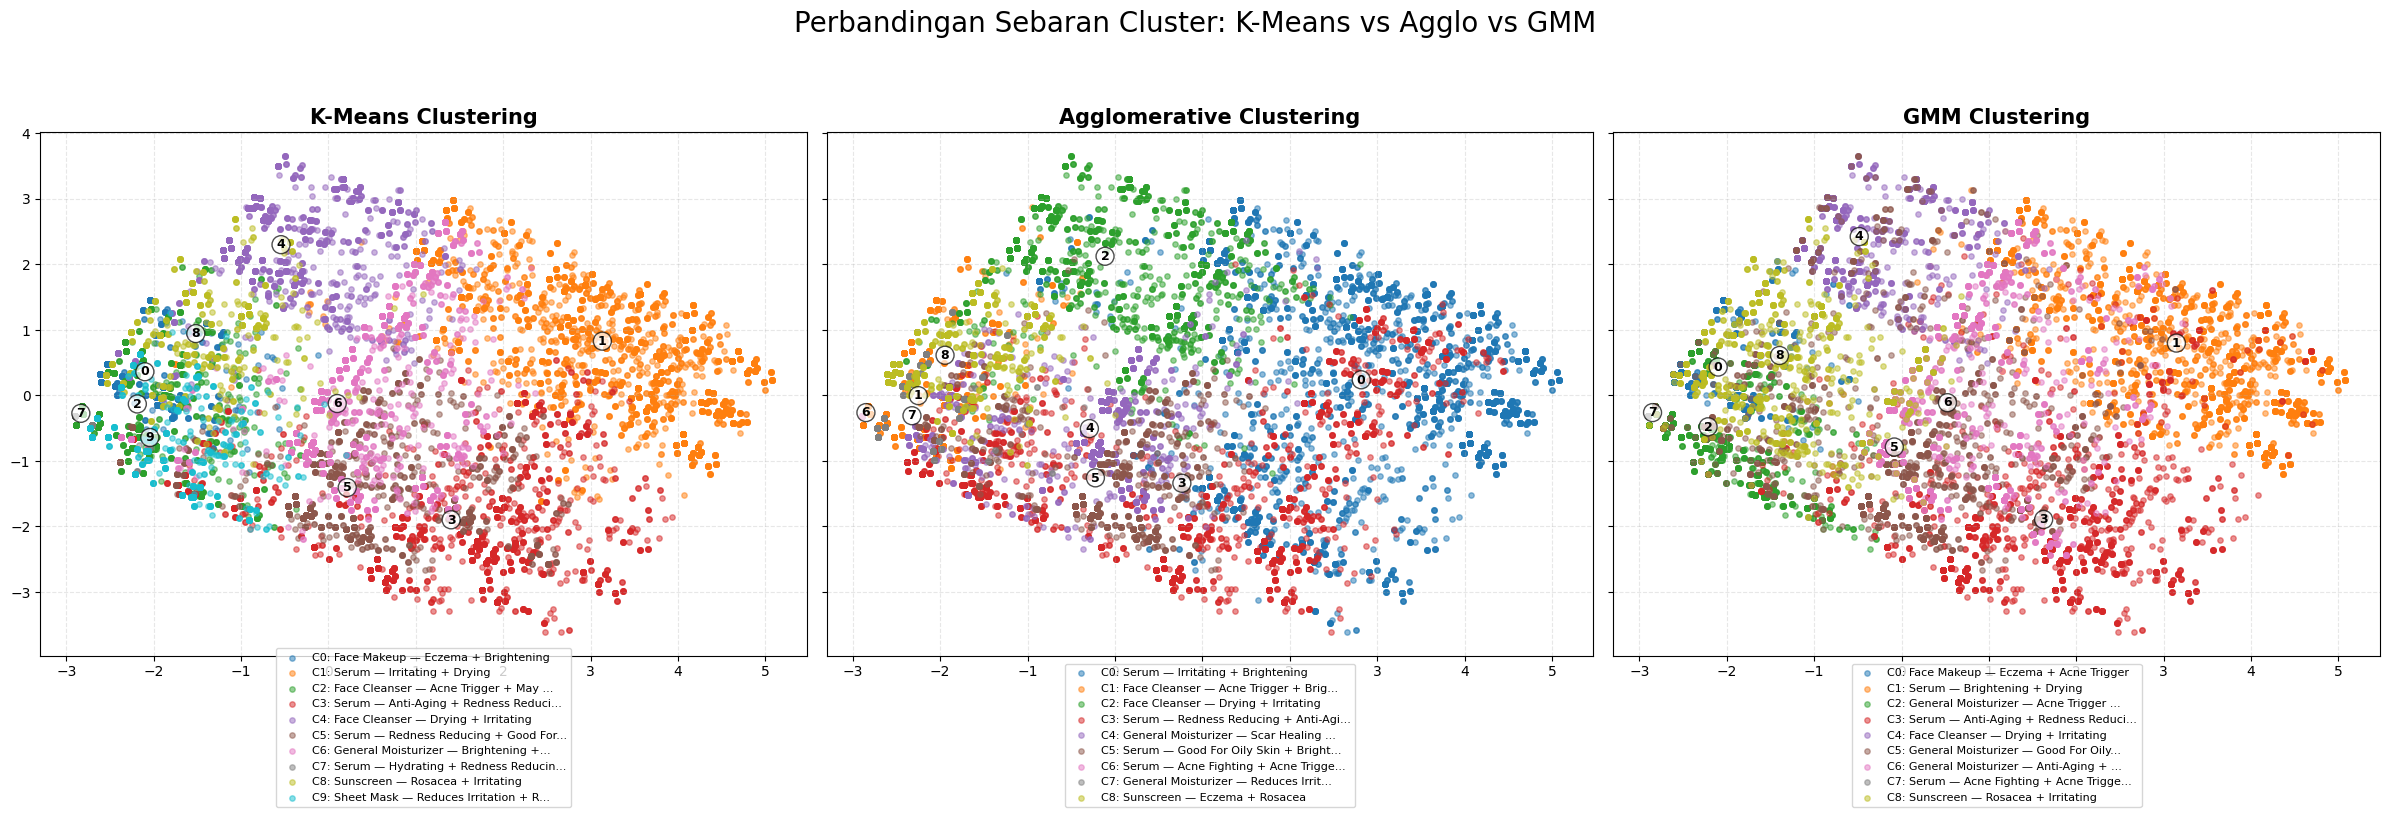

In [7]:
# ==========================================
# VISUALISASI PERBANDINGAN 3 ALGORITMA
# ==========================================
# Pastikan feature_cols sudah didefinisikan dan df[feature_cols] tidak kosong
# Periksa apakah 'X_2d_shared' sudah ada di lingkungan kernel
if 'X_2d_shared' not in locals() and 'X_2d_shared' not in globals():
    # Skala data terlebih dahulu (penting untuk PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[feature_cols])

    # Lakukan PCA untuk mengurangi ke 2 dimensi
    pca = PCA(n_components=2, random_state=42)
    X_2d_shared = pca.fit_transform(X_scaled)


# Konfigurasi plot: 1 baris, 3 kolom
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# List konfigurasi untuk looping
configs = [
    {
        'title': 'K-Means Clustering',
        'labels': df['cluster_kmeans'],
        'dict_labels': cluster_labels_kmeans,
        'col': 0
    },
    {
        'title': 'Agglomerative Clustering',
        'labels': df['cluster_agg'],
        'dict_labels': cluster_labels_agg,
        'col': 1
    },
    {
        'title': 'GMM Clustering',
        'labels': df['cluster_gmm'],
        'dict_labels': cluster_labels_gmm,
        'col': 2
    }
]

for conf in configs:
    ax = axes[conf['col']]

    # Plot setiap cluster unik dalam algoritma tersebut
    unique_clusters = sorted(conf['labels'].unique())

    for c in unique_clusters:
        mask = conf['labels'] == c
        label_text = conf['dict_labels'][c]

        # Plot titik-titik (menggunakan X_2d_shared agar posisi konsisten)
        ax.scatter(
            X_2d_shared[mask, 0],
            X_2d_shared[mask, 1],
            alpha=0.5,
            s=15,
            label=f"C{c}: {label_text[:35]}..." if len(label_text) > 35 else f"C{c}: {label_text}"
        )

        # Tambahkan anotasi nomor cluster di tengah
        cx = X_2d_shared[mask, 0].mean()
        cy = X_2d_shared[mask, 1].mean()
        ax.annotate(
            f"{c}", (cx, cy),
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='circle,pad=0.2', fc='white', ec='black', alpha=0.7)
        )

    ax.set_title(conf['title'], fontsize=15, fontweight='bold')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), fontsize=8, ncol=1)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle("Perbandingan Sebaran Cluster: K-Means vs Agglo vs GMM", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

**PROFILING CLUSTER**

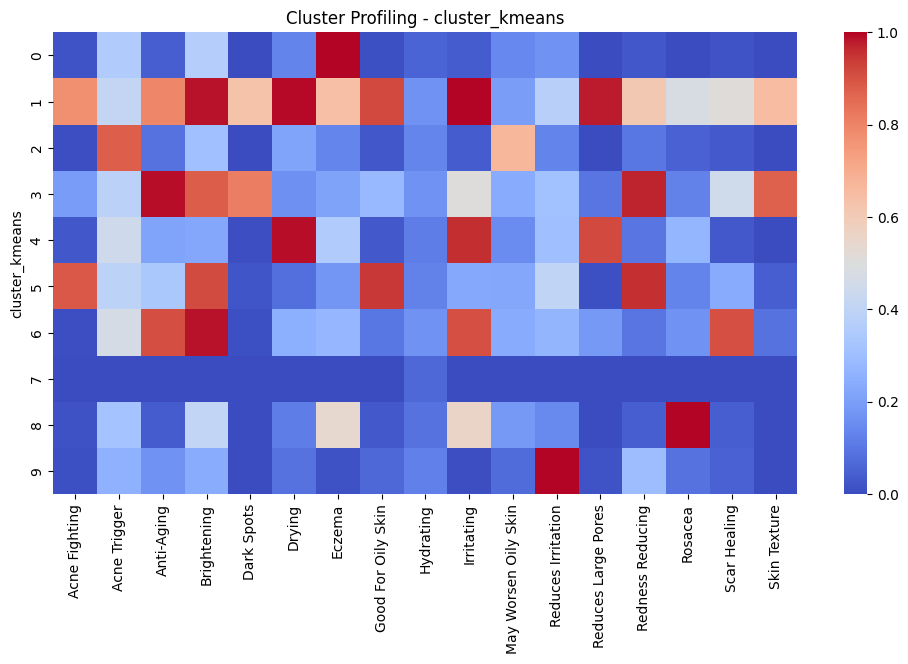

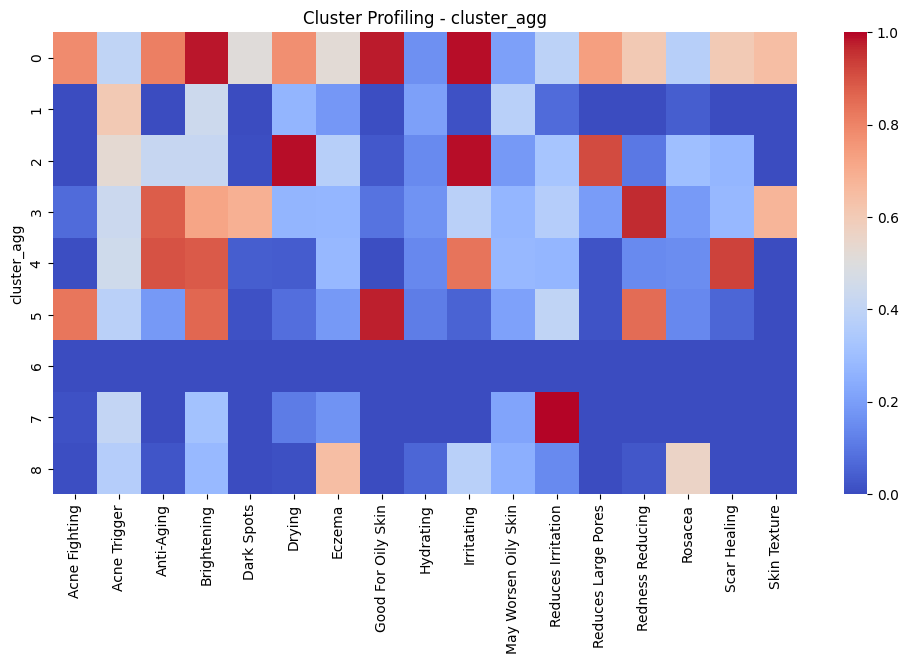

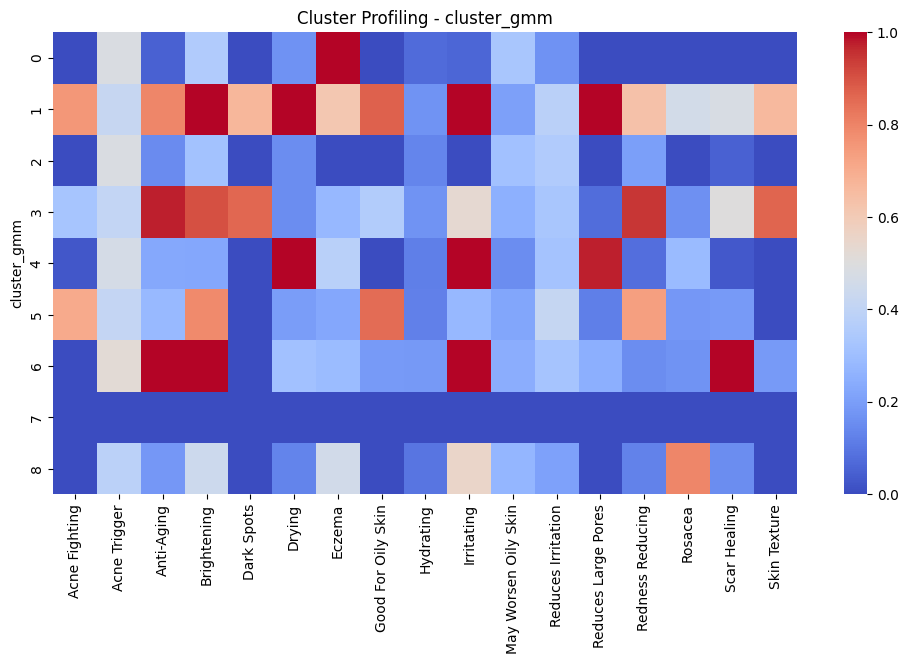

In [8]:
def plot_cluster_heatmap(df, cluster_col, feature_cols):
    profile = df.groupby(cluster_col)[feature_cols].mean()

    plt.figure(figsize=(12,6))
    sns.heatmap(profile, cmap='coolwarm')
    plt.title(f'Cluster Profiling - {cluster_col}')
    plt.show()


for col in cluster_cols:
    plot_cluster_heatmap(df, col, feature_cols)

**ANALISIS OVERLAP**

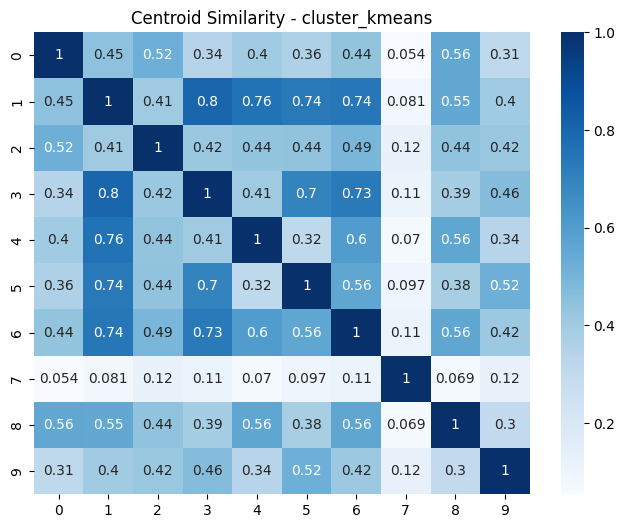

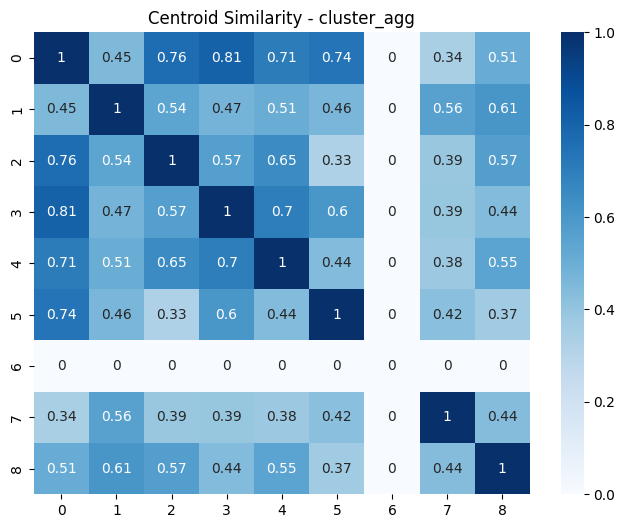

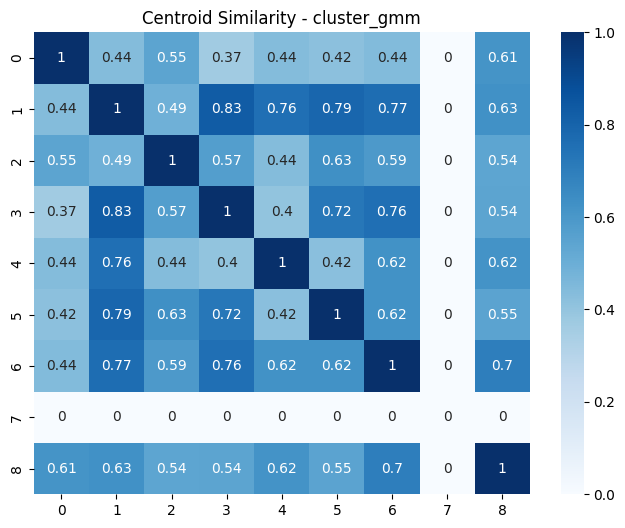

In [9]:
def centroid_similarity(df, cluster_col, feature_cols):
    centroids = df.groupby(cluster_col)[feature_cols].mean()
    sim = cosine_similarity(centroids)

    plt.figure(figsize=(8,6))
    sns.heatmap(sim, annot=True, cmap='Blues')
    plt.title(f'Centroid Similarity - {cluster_col}')
    plt.show()

    return sim


sim_kmeans = centroid_similarity(df, 'cluster_kmeans', feature_cols)
sim_agg = centroid_similarity(df, 'cluster_agg', feature_cols)
sim_gmm = centroid_similarity(df, 'cluster_gmm', feature_cols)

df_sample = df.sample(min(5000, len(df)), random_state=42)

**STABILITY & CONSISTENCY**

In [10]:
# GANTI fungsi stability_kmeans dan pemanggilannya:
def stability_cross_algo(df, col1='cluster_kmeans',
                              col2='cluster_agg'):
    ari = adjusted_rand_score(df[col1], df[col2])
    return ari

ari_km_agg = stability_cross_algo(df, 'cluster_kmeans', 'cluster_agg')
ari_km_gmm = stability_cross_algo(df, 'cluster_kmeans', 'cluster_gmm')
ari_agg_gmm = stability_cross_algo(df, 'cluster_agg', 'cluster_gmm')

print(f"ARI KMeans vs Agglo : {ari_km_agg:.4f}")
print(f"ARI KMeans vs GMM   : {ari_km_gmm:.4f}")
print(f"ARI Agglo vs GMM    : {ari_agg_gmm:.4f}")

ARI KMeans vs Agglo : 0.5456
ARI KMeans vs GMM   : 0.6617
ARI Agglo vs GMM    : 0.4765


**DISTRIBUSI CLUSTER**

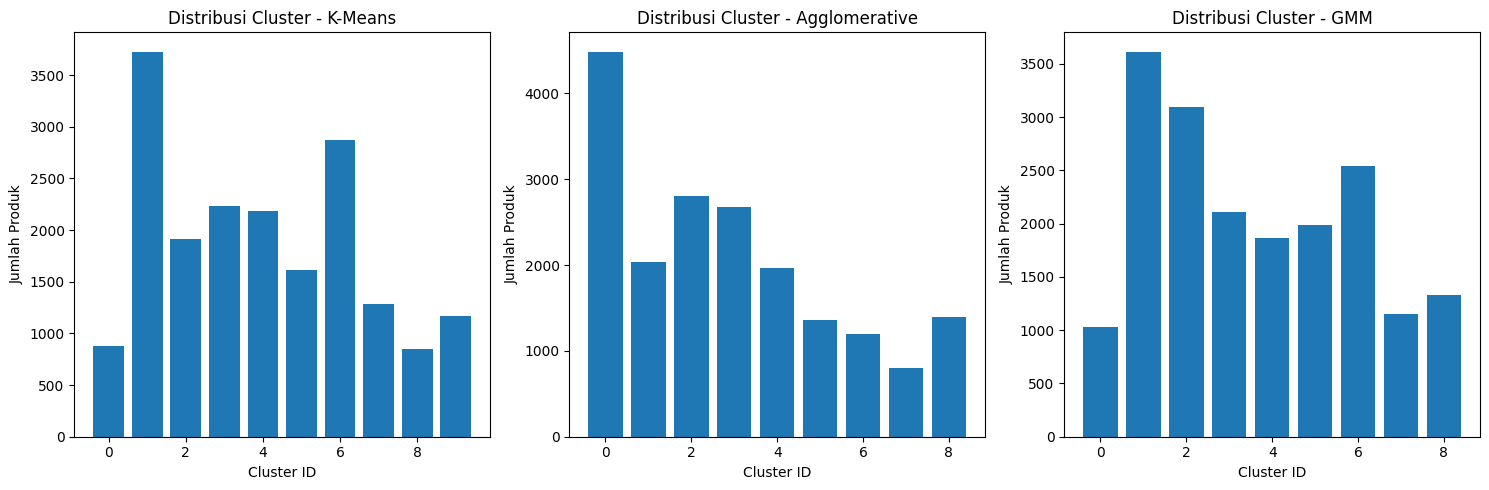

In [11]:
# GANTI seluruh bagian DISTRIBUSI CLUSTER dengan ini:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(
    axes,
    ['cluster_kmeans', 'cluster_agg', 'cluster_gmm'],
    ['K-Means', 'Agglomerative', 'GMM']
):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f'Distribusi Cluster - {title}')
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('Jumlah Produk')

plt.tight_layout()
plt.show()

**DETEKSI CLUSTER KECIL**

In [12]:
cluster_sizes = df['cluster_kmeans'].value_counts()

small_clusters = cluster_sizes[cluster_sizes / len(df) < 0.02]

print("Small clusters (<2%):")
print(small_clusters)

Small clusters (<2%):
Series([], Name: count, dtype: int64)


**EVALUASI DAN FINAL SCORING**

In [13]:
results_df = df_metrics.copy()

# Calculate an average ARI score for each algorithm based on consistency with others
stability_kmeans = (ari_km_agg + ari_km_gmm) / 2
stability_agglomerative = (ari_km_agg + ari_agg_gmm) / 2
stability_gmm = (ari_km_gmm + ari_agg_gmm) / 2

# stability mapping
stability_map = {
    "K-Means": stability_kmeans,
    "Agglomerative": stability_agglomerative,
    "GMM": stability_gmm
}

results_df["Stability"] = results_df["Algorithm"].map(stability_map)

# normalize DBI
results_df["DBI_norm"] = 1 - (
    (results_df["Davies_Bouldin_Index"] - results_df["Davies_Bouldin_Index"].min()) /
    (results_df["Davies_Bouldin_Index"].max() - results_df["Davies_Bouldin_Index"].min() + 1e-9)
)

# FINAL SCORE
results_df["FinalScore"] = (
    results_df["Silhouette_Score"] * 0.4 + # Corrected column name
    results_df["DBI_norm"] * 0.3 +
    results_df["Stability"] * 0.3
)

results_df = results_df.sort_values("FinalScore", ascending=False)

print(results_df)

       Algorithm  Best_K  Silhouette_Score  Davies_Bouldin_Index  Stability  \
0        K-Means      10          0.169545              1.848702   0.603665   
1  Agglomerative       9          0.139466              2.111269   0.511040   
2            GMM       9          0.119320              2.266582   0.569088   

       DBI_norm  FinalScore  
0  1.000000e+00    0.548917  
1  3.716701e-01    0.320599  
2  2.393031e-09    0.218455  


**SAVE SEMUA HASIL**

In [14]:
# ==========================================
# 💾 SAVE HASIL KE DRIVE (Folder: outputA)
# ==========================================
# Definisikan Path Folder outputA
OUTPUT_A_PATH = os.path.join(base_path, 'outputA')

# Buat folder jika belum ada
if not os.path.exists(OUTPUT_A_PATH):
    os.makedirs(OUTPUT_A_PATH)
    print(f"📁 Folder dibuat: {OUTPUT_A_PATH}")

# --- 1. SAVE DATAFRAME DENGAN LABEL ---
df_with_labels = df.copy()
# Pakai label K-Means sebagai representasi utama
if 'cluster_kmeans_label' not in df_with_labels.columns:
    df_with_labels['cluster_kmeans_label'] = df['cluster_kmeans'].map(cluster_labels_kmeans)

df_with_labels.to_excel(os.path.join(OUTPUT_A_PATH, 'hasil_analisis_lanjutan.xlsx'), index=False)

# --- 2. SAVE TABEL FINAL SCORING ---
results_df.to_excel(os.path.join(OUTPUT_A_PATH, 'final_scoring_algoritma.xlsx'), index=False)

# --- 3. SAVE PROFIL CLUSTER ---
profile_data = afteruse_df_reload.copy()
profile_data['cluster'] = df['cluster_kmeans'].values
cluster_profile_save = profile_data.groupby('cluster').mean().round(4)
cluster_profile_save.index = [cluster_labels_kmeans.get(i, f"Cluster {i}") for i in cluster_profile_save.index]

cluster_profile_save.to_excel(os.path.join(OUTPUT_A_PATH, 'profil_cluster_kmeans.xlsx'))

# --- 4. SAVE ARI SCORES ---
ari_data = pd.DataFrame({
    'Perbandingan': ['KMeans vs Agglo', 'KMeans vs GMM', 'Agglo vs GMM'],
    'ARI_Score': [ari_km_agg, ari_km_gmm, ari_agg_gmm]
})
ari_data.to_excel(os.path.join(OUTPUT_A_PATH, 'stabilitas_ari.xlsx'), index=False)

# --- 5. SAVE NAMA CLUSTER (JSON) ---
cluster_names_json = {str(k): v for k, v in cluster_labels_kmeans.items()}
with open(os.path.join(OUTPUT_A_PATH, 'cluster_names_kmeans.json'), 'w') as f:
    json.dump(cluster_names_json, f, indent=2, ensure_ascii=False)

print(f"\n✅ Semua file berhasil disimpan di Drive folder: {OUTPUT_A_PATH}")


✅ Semua file berhasil disimpan di Drive folder: /content/drive/My Drive/Machine_Learning/Proyek/outputA
